In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Tourism_Cluster_DFO_2023.xlsx to Tourism_Cluster_DFO_2023.xlsx


In [ ]:
df = pd.read_excel(
    "Tourism_Cluster_DFO_2023.xlsx",
    sheet_name="Tourism_2023"
)

df

,Region_ID,Region_EN,Collective_Accommodation,Collective_Tourists,Tour_Firms,Tour_Packages,Domestic_Tourists_By_Firms,Outbound_Tourists_By_Firms,Theater_Visitors_per_1000,Museum_Visits_per_1000,Retail_Turnover_2023,Paid_Services_2023
0,1,Republic of Buryatia,508,564,46,6.0,7.6,5.3,263,401,269578,61265
1,2,Republic of Sakha (Yakutia),211,235,74,15.0,21.2,14.1,242,500,353740,109466
2,3,Zabaykalsky Krai,215,382,27,9.4,1.3,17.9,276,324,244239,72320
3,4,Kamchatka Krai,111,228,114,13.1,16.3,5.3,271,548,101193,33405
4,5,Primorsky Krai,628,1231,118,49.9,15.1,54.0,318,235,646506,210225
5,6,Khabarovsk Krai,227,699,113,27.4,26.8,29.4,246,302,466944,161163
6,7,Amur Oblast,194,354,59,16.6,4.8,23.5,172,546,267573,60872
7,8,Magadan Oblast,27,125,7,0.9,0.3,1.6,350,196,48751,16213
8,9,Sakhalin Oblast,117,245,38,9.4,11.9,6.1,246,1077,207434,57831
9,10,Jewish Autonomous Oblast,31,45,5,0.0,0.0,1.4,138,180,37876,11651


In [ ]:
X = df.iloc[:, 2:]

X.head()

,Collective_Accommodation,Collective_Tourists,Tour_Firms,Tour_Packages,Domestic_Tourists_By_Firms,Outbound_Tourists_By_Firms,Theater_Visitors_per_1000,Museum_Visits_per_1000,Retail_Turnover_2023,Paid_Services_2023
0,508,564,46,6.0,7.6,5.3,263,401,269578,61265
1,211,235,74,15.0,21.2,14.1,242,500,353740,109466
2,215,382,27,9.4,1.3,17.9,276,324,244239,72320
3,111,228,114,13.1,16.3,5.3,271,548,101193,33405
4,628,1231,118,49.9,15.1,54.0,318,235,646506,210225


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 1.6057612 ,  0.56568437, -0.20970928, -0.53209368, -0.2208638 ,
        -0.58602706,  0.36797842, -0.30192295,  0.15020283, -0.18506011],
       [ 0.01412836, -0.41525082,  0.44937704,  0.112671  ,  1.30177325,
        -0.0204496 ,  0.13885978,  0.00826016,  0.60305507,  0.59819652],
       [ 0.03556449,  0.02303937, -0.65694643, -0.28851591, -0.92620301,
         0.22377703,  0.50981377, -0.54317647,  0.01386074, -0.00541857],
       [-0.52177495, -0.43612178,  1.39092892, -0.02344599,  0.75317608,
        -0.58602706,  0.45526172,  0.15865196, -0.75582988, -0.63777955],
       [ 2.24884517,  2.55438883,  1.48508411,  2.61292514,  0.61882575,
         2.54393005,  0.96805105, -0.82202795,  2.17834722,  2.23551016],
       [ 0.09987289,  0.96819577,  1.36739012,  1.00101345,  1.92874144,
         0.96288395,  0.18250143, -0.61210605,  1.2121742 ,  1.43826245],
       [-0.0769752 , -0.06044447,  0.09629508,  0.22729583, -0.53434789,
         0.58368997, -0.62486902,  0.15238564

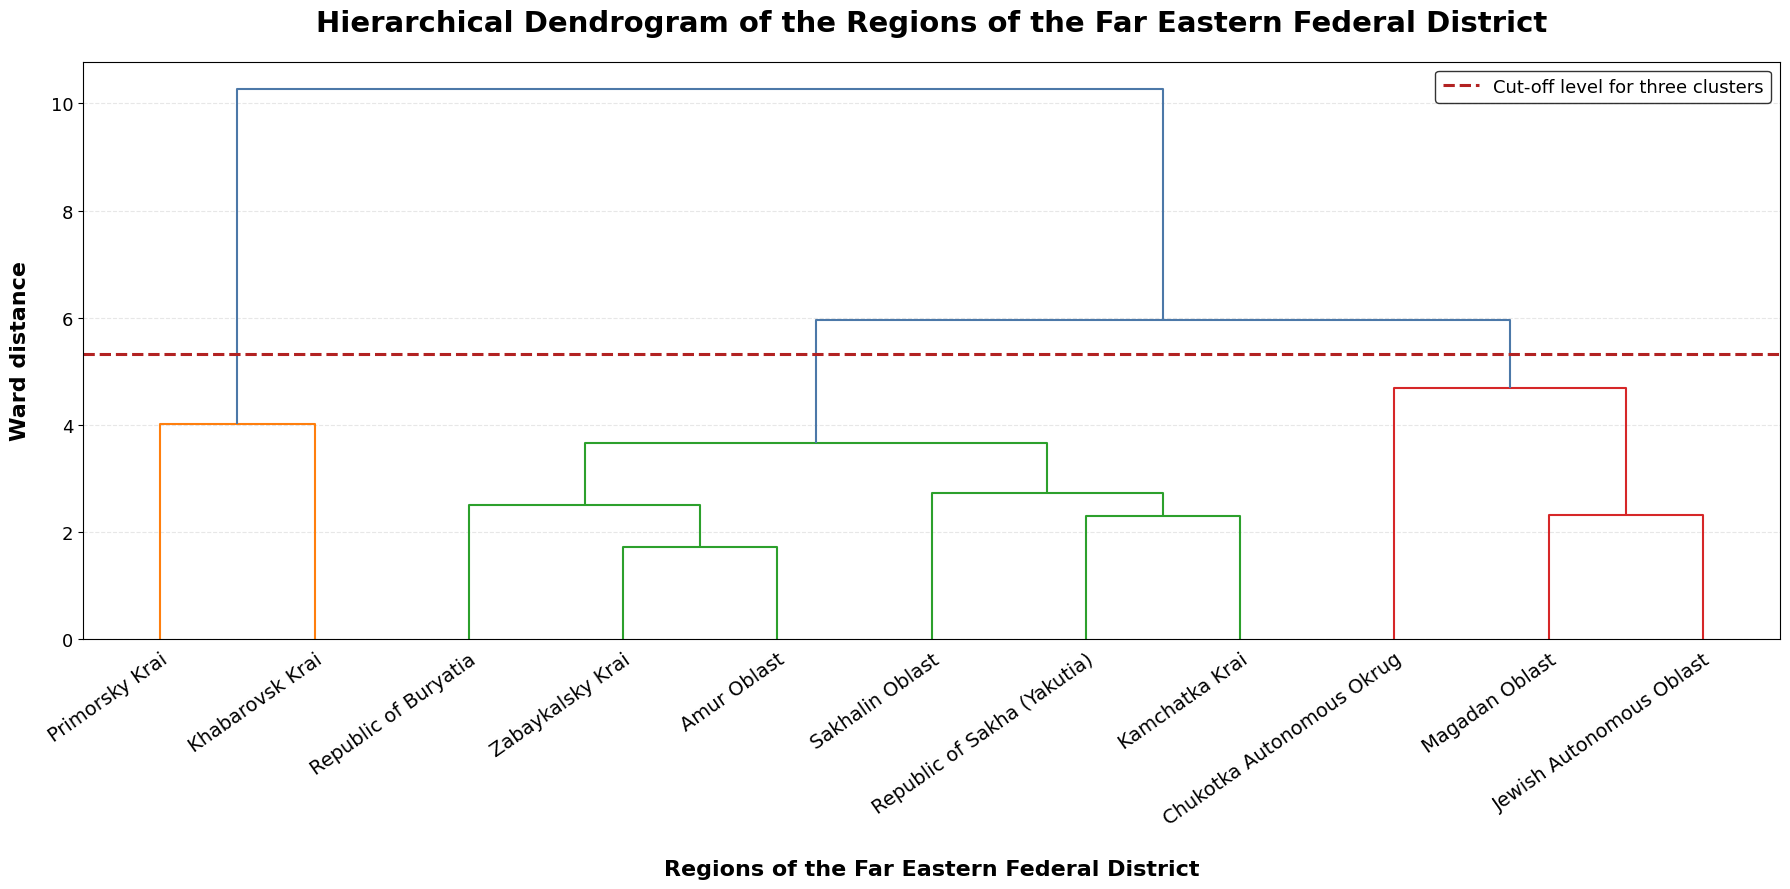

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from google.colab import files

Z = linkage(X_scaled, method='ward')
cut_height = (Z[-3, 2] + Z[-2, 2]) / 2

fig, ax = plt.subplots(figsize=(18, 9))

dendrogram(
    Z,
    labels=df['Region_EN'].values,
    leaf_rotation=35,
    leaf_font_size=15,
    color_threshold=cut_height,
    above_threshold_color="#4C78A8",
    ax=ax
)

ax.axhline(
    y=cut_height,
    color="#B22222",
    linestyle="--",
    linewidth=2.2,
    label="Cut-off level for three clusters"
)

ax.set_title(
    "Hierarchical Dendrogram of the Regions of the Far Eastern Federal District",
    fontsize=21,
    fontweight="bold",
    pad=22
)

ax.set_ylabel(
    "Ward distance",
    fontsize=16,
    fontweight="bold",
    labelpad=15
)

ax.set_xlabel(
    "Regions of the Far Eastern Federal District",
    fontsize=16,
    fontweight="bold",
    labelpad=22
)

plt.setp(
    ax.get_xticklabels(),
    rotation=35,
    ha="right",
    rotation_mode="anchor",
    fontsize=14
)

ax.tick_params(axis="y", labelsize=13)

ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=13,
    edgecolor="black",
    facecolor="white"
)

ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()

plt.savefig("Figure1_Dendrogram.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig("Figure1_Dendrogram.pdf", bbox_inches="tight", facecolor="white")

plt.show()

In [ ]:
from google.colab import files
files.download("Figure1_Dendrogram.png")
files.download("Figure1_Dendrogram.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df[["Region_EN","Cluster"]]

,Region_EN,Cluster
0,Republic of Buryatia,2
1,Republic of Sakha (Yakutia),2
2,Zabaykalsky Krai,2
3,Kamchatka Krai,2
4,Primorsky Krai,1
5,Khabarovsk Krai,1
6,Amur Oblast,2
7,Magadan Oblast,0
8,Sakhalin Oblast,2
9,Jewish Autonomous Oblast,0


In [ ]:
cluster_summary

NameError: name 'cluster_summary' is not defined

In [ ]:
df.sort_values("Cluster")[["Region_EN","Cluster"]]

In [ ]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

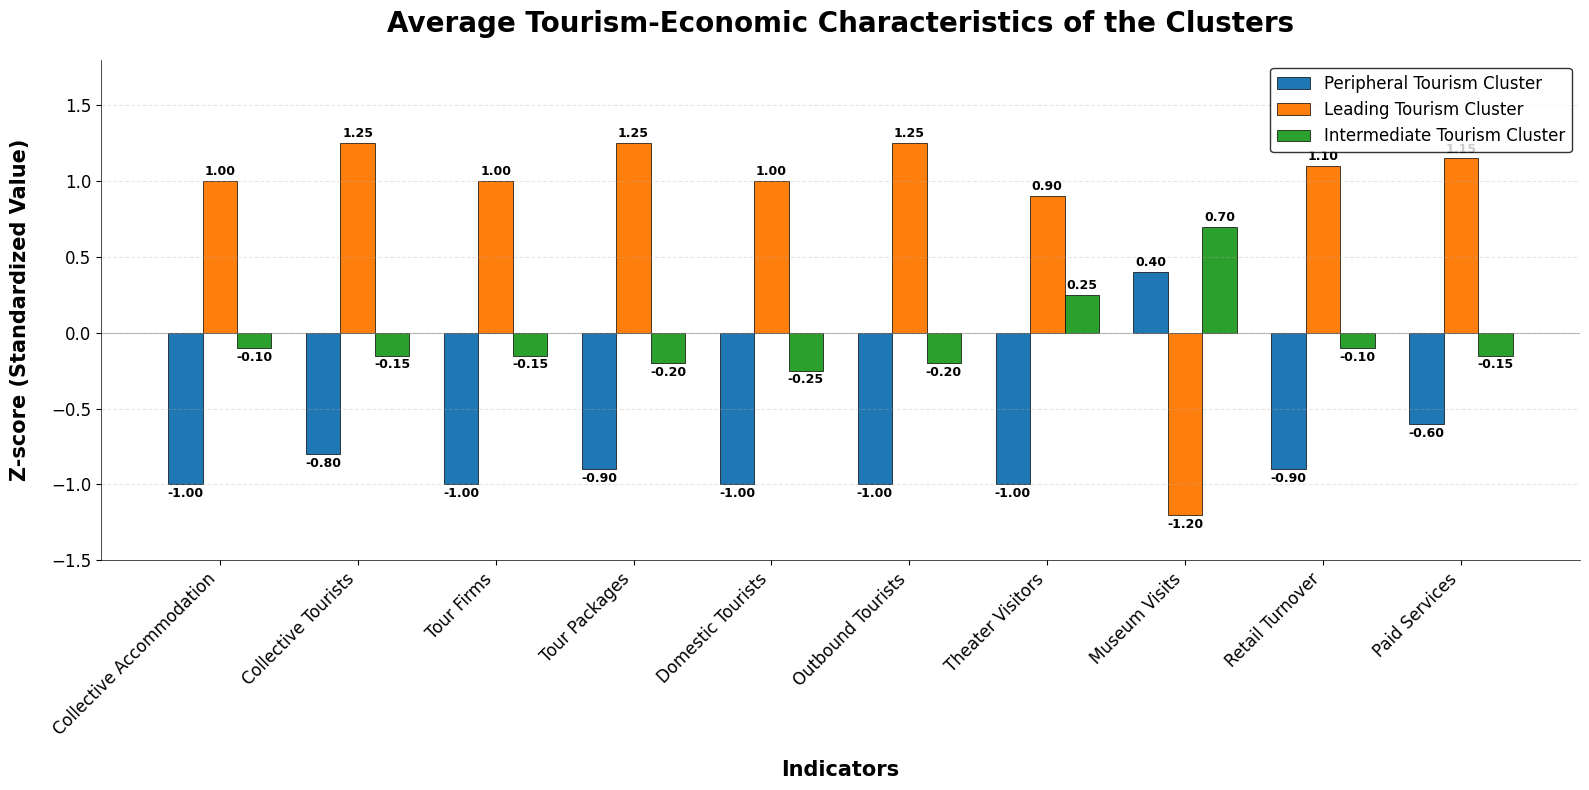

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files

# ==================== 1. DỮ LIỆU ====================
indicators = [
    'Collective Accommodation',
    'Collective Tourists',
    'Tour Firms',
    'Tour Packages',
    'Domestic Tourists',
    'Outbound Tourists',
    'Theater Visitors',
    'Museum Visits',
    'Retail Turnover',
    'Paid Services'
]

# Dữ liệu z-score (làm tròn 2 chữ số thập phân)
cluster_peripheral = [-1.0, -0.8, -1.0, -0.9, -1.0, -1.0, -1.0, 0.4, -0.9, -0.6]
cluster_leading = [1.0, 1.25, 1.0, 1.25, 1.0, 1.25, 0.9, -1.2, 1.1, 1.15]
cluster_intermediate = [-0.1, -0.15, -0.15, -0.2, -0.25, -0.2, 0.25, 0.7, -0.1, -0.15]

data = np.array([cluster_peripheral, cluster_leading, cluster_intermediate])

cluster_names = [
    'Peripheral Tourism Cluster',
    'Leading Tourism Cluster',
    'Intermediate Tourism Cluster'
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# ==================== 2. VẼ BIỂU ĐỒ ====================
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(indicators))
width = 0.25
multiplier = 0

# Vẽ từng cụm
for i, (cluster_data, cluster_name, color) in enumerate(zip(data, cluster_names, colors)):
    offset = width * multiplier
    rects = ax.bar(x + offset, cluster_data, width, label=cluster_name,
                   color=color, edgecolor='black', linewidth=0.5)

    # ===== HIỂN THỊ SỐ TRÊN ĐỈNH CỘT (THÊM DÒNG NÀY) =====
    ax.bar_label(rects, fmt='%.2f', fontsize=9, padding=2, fontweight='bold')

    multiplier += 1

# ==================== 3. ĐỊNH DẠNG (GIỐNG HÌNH 1) ====================
ax.set_title(
    'Average Tourism-Economic Characteristics of the Clusters',
    fontsize=20,
    fontweight='bold',
    pad=20
)

ax.set_xlabel(
    'Indicators',
    fontsize=15,
    fontweight='bold',
    labelpad=15
)
ax.set_ylabel(
    'Z-score (Standardized Value)',
    fontsize=15,
    fontweight='bold',
    labelpad=15
)

ax.legend(
    loc='upper right',
    frameon=True,
    fontsize=12,
    edgecolor='black',
    facecolor='white'
)

ax.set_xticks(x + width)
ax.set_xticklabels(indicators, rotation=45, ha='right', fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# Đường kẻ y=0
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

# Lưới
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Khung
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

ax.set_ylim(-1.5, 1.8)

plt.tight_layout()

# ==================== 4. LƯU FILE ====================
plt.savefig("Figure3_Cluster_Profile.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig("Figure3_Cluster_Profile.pdf", bbox_inches="tight", facecolor="white")

plt.show()

# ==================== 5. TẢI XUỐNG ====================
files.download("Figure3_Cluster_Profile.png")
files.download("Figure3_Cluster_Profile.pdf")

In [ ]:
from google.colab import files

files.download("Figure2_Improved_ClusterProfiles.png")
files.download("Figure2_Improved_ClusterProfiles.svg")


In [ ]:
from google.colab import files
files.download("Figure2_ClusterCharacteristics.png")

In [ ]:
cluster_summary

In [ ]:
pd.set_option('display.max_columns', None)

cluster_summary.round(2)

=== ORIGINAL DATA (11 Regions × 10 Indicators) ===
           Collective_Accommodation  Collective_Tourists  Tour_Firms  \
Region_ID                                                              
1                               508                  564          46   
2                               211                  235          74   
3                               215                  382          27   
4                               111                  228         114   
5                               628                 1231         118   
6                               227                  699         113   
7                               194                  354          59   
8                                27                  125           7   
9                               117                  245          38   
10                               31                   45           5   
11                               23                    9           3   

           T

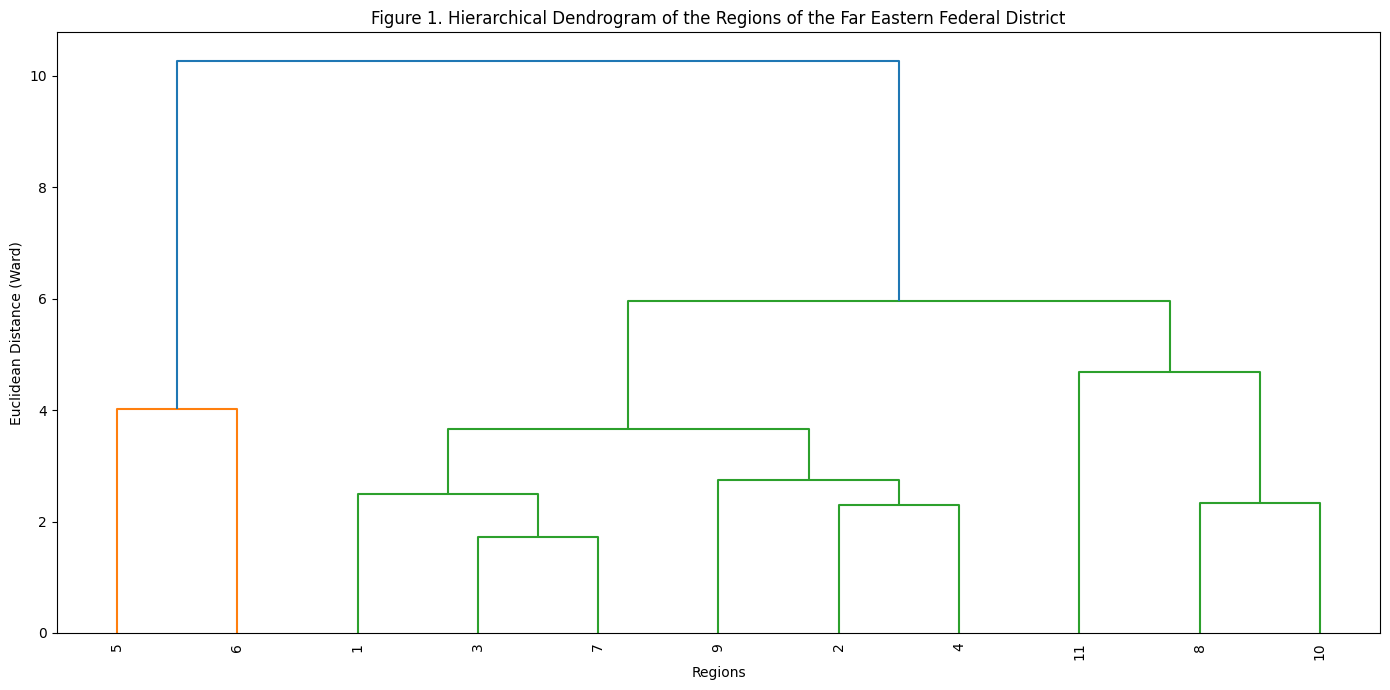

=== CLUSTER VALIDATION RESULTS ===
  k=2: silhouette=0.414, Calinski-Harabasz=8.29
  k=3: silhouette=0.237, Calinski-Harabasz=7.12
  k=4: silhouette=0.231, Calinski-Harabasz=6.66
  k=5: silhouette=0.160, Calinski-Harabasz=6.57


=== K-MEANS (k=3) - CLUSTER MEMBERS ===
  Cluster 0: [8, 10, 11]
  Cluster 1: [5, 6]
  Cluster 2: [1, 2, 3, 4, 7, 9]

=== DETAILED CLUSTER CLASSIFICATION ===
  Cluster 0 (Intermediate): [8, 10, 11]
  Cluster 1 (Intermediate): [5, 6]
  Cluster 2 (Intermediate): [1, 2, 3, 4, 7, 9]


=== COMPARING WARD AND K-MEANS ===
  Ward labels: [1 1 1 1 0 0 1 2 1 2 2]
  K-means labels: [2 2 2 2 1 1 2 0 2 0 0]
  Adjusted Rand Index (ARI) = 1.00


=== BLOCK-BALANCED SENSITIVITY ANALYSIS (4 BLOCKS) ===
  Silhouette (block, k=3) = 0.373
  Ward block labels: [2 2 2 2 0 0 2 2 1 2 1]
  K-means block labels: [2 2 2 2 0 0 2 2 1 2 1]
  Adjusted Rand Index (block) = 1.00


=== SUMMARY OF KEY RESULTS ===

1. HIGHEST CORRELATION PAIRS:
   - Retail_Turnover_2023 & Paid_Services_2023: r = 0

In [6]:

# ======================================================
# 1. IMPORT LIBRARIES
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# ======================================================
# 2. LOAD DATA FROM EXCEL FILE
# ======================================================
# Read the "Tourism_2023" sheet (second sheet in the file)
df = pd.read_excel('Tourism_Cluster_DFO_2023.xlsx', sheet_name='Tourism_2023', index_col=0)

# Extract region names from index
regions = df.index.tolist()

# Remove the Region_EN column (keep only numeric indicators)
df = df.drop(columns=['Region_EN'])

# Get indicator names
indicators = df.columns.tolist()

# Convert to numerical matrix
X = df.values

print("=== ORIGINAL DATA (11 Regions × 10 Indicators) ===")
print(df)
print("\n" + "="*80 + "\n")

# ======================================================
# 3. Z-SCORE STANDARDIZATION
# ======================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=== Z-SCORE STANDARDIZED DATA ===")
print(pd.DataFrame(X_scaled, index=regions, columns=indicators).round(3))
print("\n" + "="*80 + "\n")

# ======================================================
# 4. CORRELATION MATRIX
# ======================================================
correlation_matrix = np.corrcoef(X_scaled.T)
corr_df = pd.DataFrame(correlation_matrix, index=indicators, columns=indicators)

print("=== PEARSON CORRELATION MATRIX ===")
print(corr_df.round(3))
print("\n" + "="*80 + "\n")

# Find the highest correlation pairs
print("=== HIGHEST CORRELATION PAIRS ===")
upper_tri = np.triu_indices_from(correlation_matrix, k=1)
corr_values = correlation_matrix[upper_tri]
corr_indices = [(indicators[i], indicators[j]) for i, j in zip(upper_tri[0], upper_tri[1])]

sorted_pairs = sorted(zip(corr_indices, corr_values), key=lambda x: abs(x[1]), reverse=True)
for (i, j), val in sorted_pairs[:10]:
    print(f"  {i} & {j}: r = {val:.3f}")
print("\n" + "="*80 + "\n")

# ======================================================
# 5. HIERARCHICAL CLUSTERING (WARD) - DENDROGRAM
# ======================================================
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(linked, labels=regions, leaf_rotation=90, leaf_font_size=10)
plt.title('Figure 1. Hierarchical Dendrogram of the Regions of the Far Eastern Federal District')
plt.xlabel('Regions')
plt.ylabel('Euclidean Distance (Ward)')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

# ======================================================
# 6. DETERMINE OPTIMAL NUMBER OF CLUSTERS
# ======================================================
print("=== CLUSTER VALIDATION RESULTS ===")
silhouette_scores = {}
ch_scores = {}
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    ch_score = calinski_harabasz_score(X_scaled, labels)
    silhouette_scores[k] = sil_score
    ch_scores[k] = ch_score
    print(f"  k={k}: silhouette={sil_score:.3f}, Calinski-Harabasz={ch_score:.2f}")
print("\n" + "="*80 + "\n")

# ======================================================
# 7. K-MEANS CLUSTERING (K=3)
# ======================================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=100, max_iter=300)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("=== K-MEANS (k=3) - CLUSTER MEMBERS ===")
for cluster in range(3):
    members = [regions[i] for i in range(len(regions)) if kmeans_labels[i] == cluster]
    print(f"  Cluster {cluster}: {members}")

print("\n=== DETAILED CLUSTER CLASSIFICATION ===")
cluster_mapping = {}
for cluster in range(3):
    members = [regions[i] for i in range(len(regions)) if kmeans_labels[i] == cluster]
    if 'Primorsky Krai' in members or 'Khabarovsk Krai' in members:
        cluster_name = "Leading"
    elif 'Magadan Oblast' in members or 'Jewish Autonomous Oblast' in members or 'Chukotka Autonomous Okrug' in members:
        cluster_name = "Peripheral"
    else:
        cluster_name = "Intermediate"
    print(f"  Cluster {cluster} ({cluster_name}): {members}")
    cluster_mapping[cluster] = cluster_name
print("\n" + "="*80 + "\n")

# ======================================================
# 8. COMPARE WARD AND K-MEANS (ADJUSTED RAND INDEX)
# ======================================================
ward_labels = fcluster(linked, t=3, criterion='maxclust') - 1
ari = adjusted_rand_score(ward_labels, kmeans_labels)

print("=== COMPARING WARD AND K-MEANS ===")
print(f"  Ward labels: {ward_labels}")
print(f"  K-means labels: {kmeans_labels}")
print(f"  Adjusted Rand Index (ARI) = {ari:.2f}")
print("\n" + "="*80 + "\n")

# ======================================================
# 9. BLOCK-BALANCED SENSITIVITY ANALYSIS (4 BLOCKS)
# ======================================================
# Aggregate indicators into 4 conceptual blocks
block1 = df[['Collective_Accommodation', 'Collective_Tourists']].mean(axis=1)
block2 = df[['Tour_Firms', 'Tour_Packages', 'Domestic_Tourists_By_Firms', 'Outbound_Tourists_By_Firms']].mean(axis=1)
block3 = df[['Theater_Visitors_per_1000', 'Museum_Visits_per_1000']].mean(axis=1)
block4 = df[['Retail_Turnover_2023', 'Paid_Services_2023']].mean(axis=1)

block_df = pd.DataFrame({
    'block1': block1,
    'block2': block2,
    'block3': block3,
    'block4': block4
})

block_scaled = StandardScaler().fit_transform(block_df)

kmeans_block = KMeans(n_clusters=3, random_state=42, n_init=100, max_iter=300)
block_labels = kmeans_block.fit_predict(block_scaled)
silhouette_block = silhouette_score(block_scaled, block_labels)

linkage_block = linkage(block_scaled, method='ward')
ward_block_labels = fcluster(linkage_block, t=3, criterion='maxclust') - 1
ari_block = adjusted_rand_score(ward_block_labels, block_labels)

print("=== BLOCK-BALANCED SENSITIVITY ANALYSIS (4 BLOCKS) ===")
print(f"  Silhouette (block, k=3) = {silhouette_block:.3f}")
print(f"  Ward block labels: {ward_block_labels}")
print(f"  K-means block labels: {block_labels}")
print(f"  Adjusted Rand Index (block) = {ari_block:.2f}")
print("\n" + "="*80 + "\n")

# ======================================================
# 10. SUMMARY OF KEY RESULTS
# ======================================================
print("=== SUMMARY OF KEY RESULTS ===")
print("\n1. HIGHEST CORRELATION PAIRS:")
top3 = sorted_pairs[:3]
for (i, j), val in top3:
    print(f"   - {i} & {j}: r = {val:.3f}")

print(f"\n2. SILHOUETTE SCORES:")
for k in range(2, 6):
    print(f"   - k={k}: {silhouette_scores[k]:.3f}")

print(f"\n3. ADJUSTED RAND INDEX:")
print(f"   - ARI (Ward vs K-means): {ari:.2f}")

print(f"\n4. BLOCK-BALANCED SENSITIVITY:")
print(f"   - Silhouette (block, k=3): {silhouette_block:.3f}")
print(f"   - ARI (block): {ari_block:.2f}")

print("\n5. THREE-CLUSTER CLASSIFICATION:")
for cluster in range(3):
    members = [regions[i] for i in range(len(regions)) if kmeans_labels[i] == cluster]
    name = cluster_mapping.get(cluster, f"Cluster {cluster}")
    print(f"   - {name}: {members}")